# Deep Learning to detect writed numbers

## Librairies

In [49]:
import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from nn import transform
import os


In [50]:
batch_size = 16
n_epochs = 30
lr = 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [51]:
device

device(type='cpu')

## Dataset

In [151]:
dataset_path = 'dataset/'
classes = range(len(os.listdir(dataset_path)))

In [153]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(root=dataset_path, transform=train_transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
n_classes = len(dataset.classes)

torch.Size([1, 96, 96]) 6


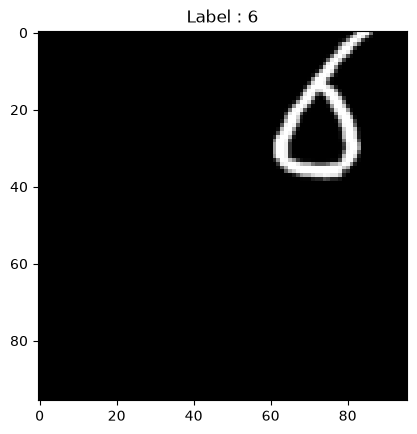

torch.Size([1, 96, 96]) 9


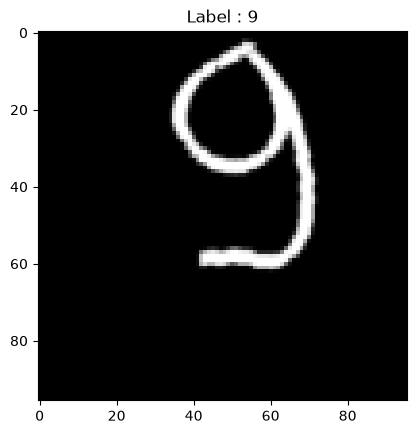

torch.Size([1, 96, 96]) 6


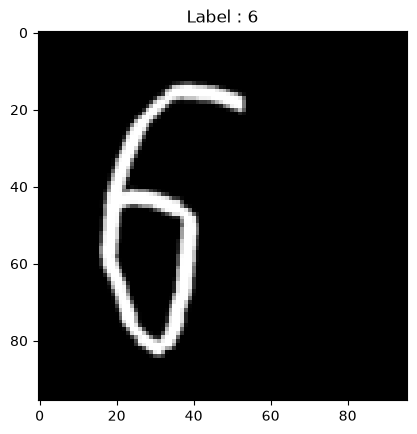

torch.Size([1, 96, 96]) 2


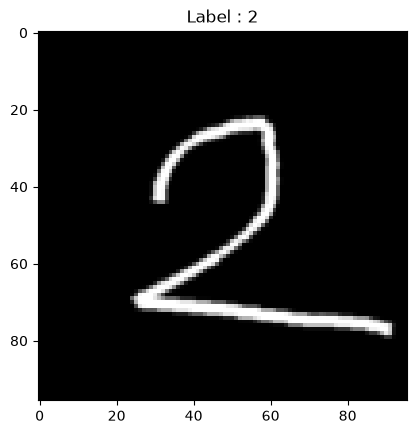

torch.Size([1, 96, 96]) 9


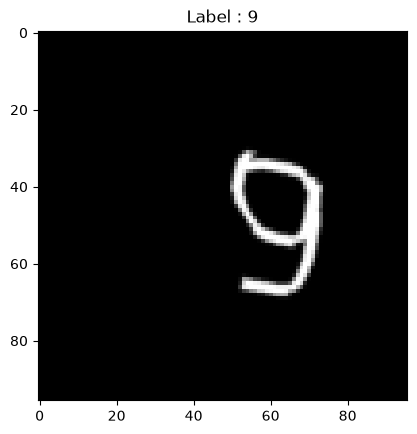

torch.Size([1, 96, 96]) 1


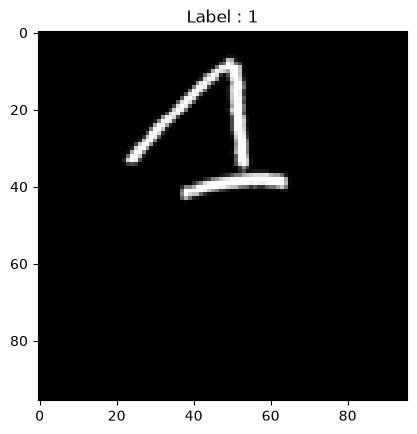

torch.Size([1, 96, 96]) 6


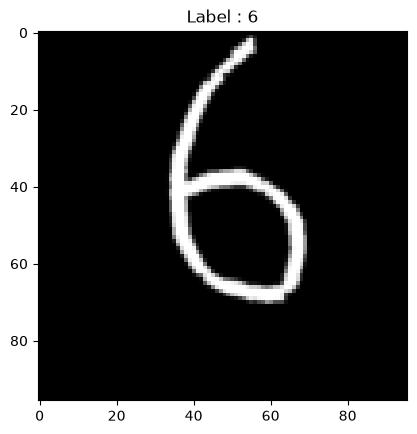

torch.Size([1, 96, 96]) 4


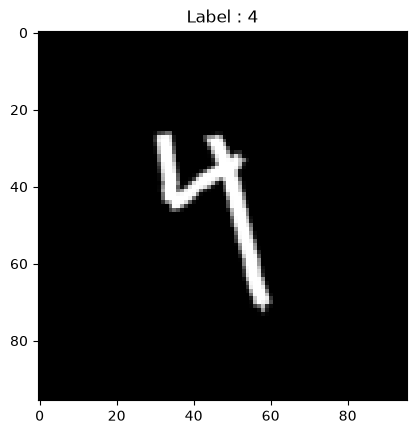

torch.Size([1, 96, 96]) 3


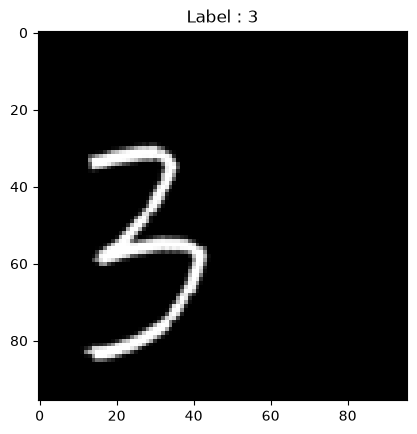

torch.Size([1, 96, 96]) 7


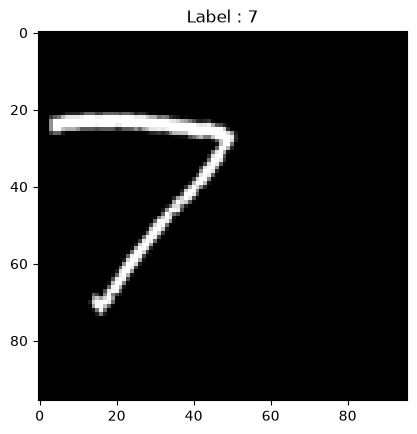

torch.Size([1, 96, 96]) 3


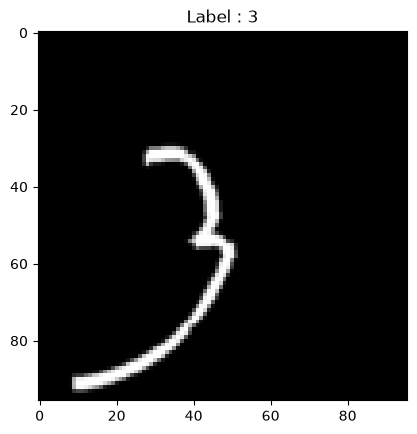

torch.Size([1, 96, 96]) 7


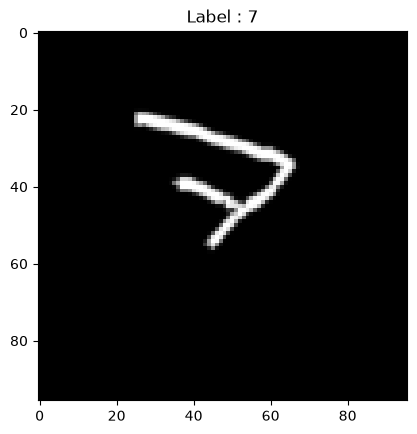

torch.Size([1, 96, 96]) 8


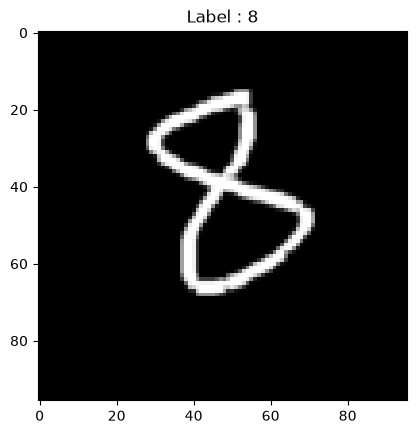

torch.Size([1, 96, 96]) 1


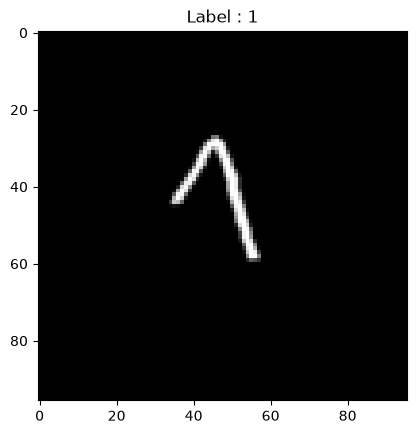

torch.Size([1, 96, 96]) 7


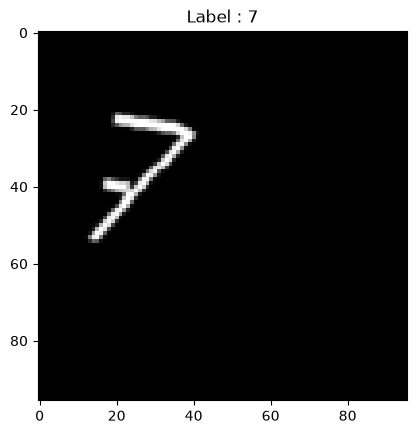

torch.Size([1, 96, 96]) 8


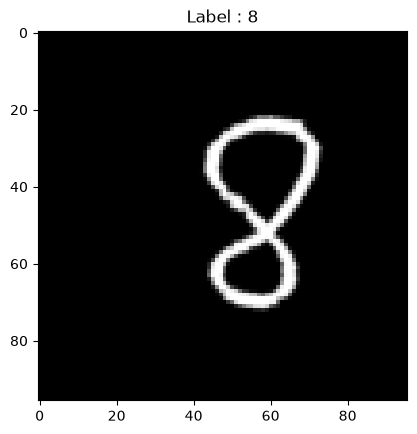

In [100]:
#Function to show an image
def imshow(img, title):
    img = img / 2 + 0.5 #unormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.title(title)
    plt.show()

#Get some random training images
dataiter = iter(dataloader)
images, labels = next(dataiter)

#Show images with labels
for i in range(len(images)):
    print(images[i].shape, labels[i].item())
    imshow(images[i],title=f'Label : {labels[i].item()}')

In [155]:
#total number of images
print(len(dataset))

900


In [154]:
n_classes

10

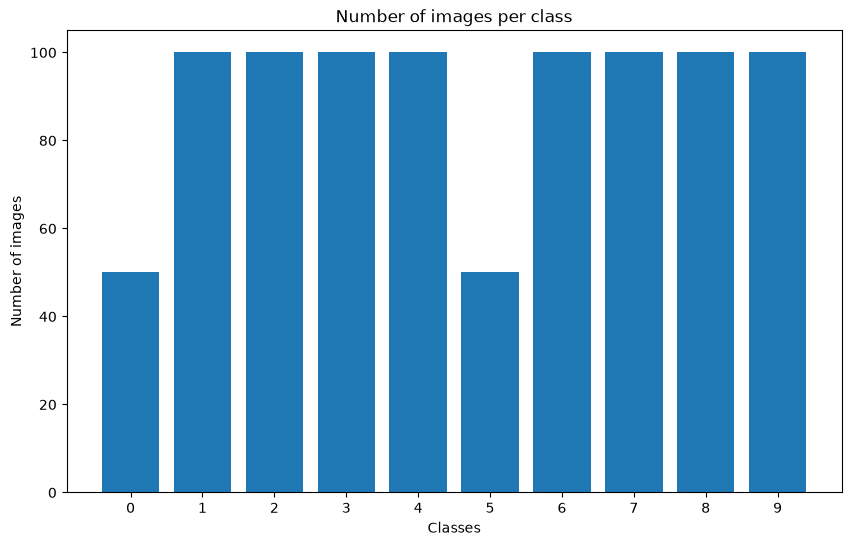

In [156]:
plt.figure(figsize=(10,6))
plt.bar(classes, [len(os.listdir(dataset_path + c)) for c in os.listdir(dataset_path)])
plt.xticks(classes)
plt.title('Number of images per class')
plt.xlabel('Classes')
plt.ylabel('Number of images')
plt.show()

## Neural Network

In [157]:
from nn import Net
net = Net(n_classes=n_classes).to(device)

In [158]:
net

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=7056, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [159]:
#number of parameters
sum(p.numel() for p in net.parameters())

860426

In [160]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=lr)

def evaluate(loader):
    net.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (net(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    net.train()
    return 100 * correct / total

for epoch in range(n_epochs):
    running_loss = 0.0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(net(inputs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f'Epoch {epoch+1}: loss={running_loss/len(dataloader):.3f} | '
          f'train={evaluate(dataloader):.1f}% | test={evaluate(test_dataloader):.1f}%')

print('Finished Training')

Epoch 1: loss=2.113 | train=34.7% | test=40.9%
Epoch 2: loss=1.759 | train=49.6% | test=61.1%
Epoch 3: loss=1.312 | train=64.1% | test=77.6%
Epoch 4: loss=0.991 | train=74.1% | test=86.8%
Epoch 5: loss=0.856 | train=76.9% | test=86.5%
Epoch 6: loss=0.718 | train=78.3% | test=88.8%
Epoch 7: loss=0.694 | train=81.8% | test=89.4%
Epoch 8: loss=0.578 | train=82.7% | test=89.1%
Epoch 9: loss=0.543 | train=87.3% | test=92.7%
Epoch 10: loss=0.496 | train=84.4% | test=91.4%
Epoch 11: loss=0.462 | train=87.6% | test=87.8%
Epoch 12: loss=0.482 | train=88.4% | test=94.1%
Epoch 13: loss=0.401 | train=88.3% | test=88.1%
Epoch 14: loss=0.349 | train=90.3% | test=91.1%
Epoch 15: loss=0.319 | train=92.2% | test=90.1%
Epoch 16: loss=0.346 | train=90.6% | test=92.1%
Epoch 17: loss=0.348 | train=91.1% | test=90.4%
Epoch 18: loss=0.318 | train=90.6% | test=92.1%
Epoch 19: loss=0.274 | train=92.1% | test=90.4%
Epoch 20: loss=0.280 | train=91.3% | test=93.4%
Epoch 21: loss=0.285 | train=92.3% | test=94.1%
E

In [161]:
#Save the model
torch.save(net.state_dict(), 'net.pth')

## Inference

### Total accuracy and accuracy per class

In [162]:
test_dataset_path = 'testdataset/'
test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)
n_classes = len(test_dataset.classes)
classes = range(len(os.listdir(test_dataset_path)))

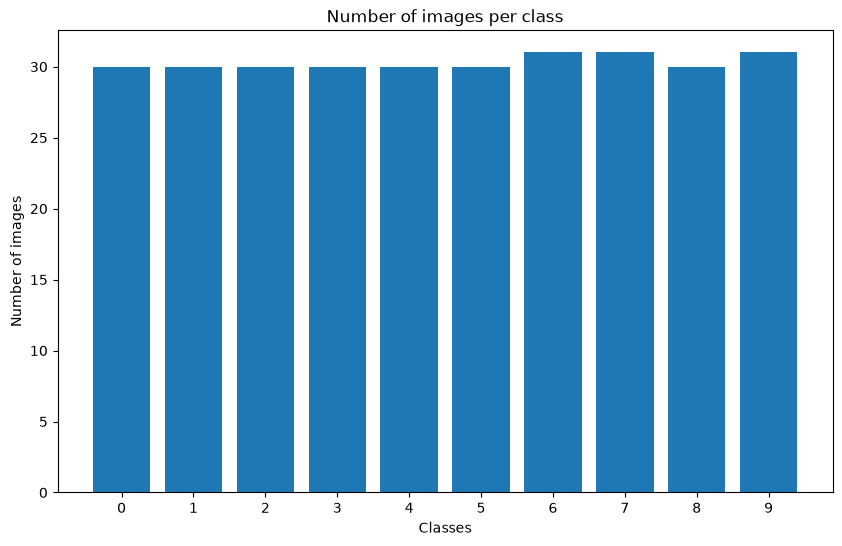

In [163]:
plt.figure(figsize=(10,6))
plt.bar(classes, [len(os.listdir(test_dataset_path + c)) for c in os.listdir(test_dataset_path)])
plt.xticks(classes)
plt.title('Number of images per class')
plt.xlabel('Classes')
plt.ylabel('Number of images')
plt.show()

In [164]:
from nn import Net
net = Net(n_classes=10).to(device)
net.load_state_dict(torch.load('net.pth'))

<All keys matched successfully>

Accuracy of the network on the test images: 93.06930693069307%
Accuracy of 0: 96.66666666666667%
Accuracy of 1: 93.33333333333333%
Accuracy of 2: 83.33333333333333%
Accuracy of 3: 93.33333333333333%
Accuracy of 4: 93.33333333333333%
Accuracy of 5: 93.33333333333333%
Accuracy of 6: 100.0%
Accuracy of 7: 96.7741935483871%
Accuracy of 8: 83.33333333333333%
Accuracy of 9: 96.7741935483871%


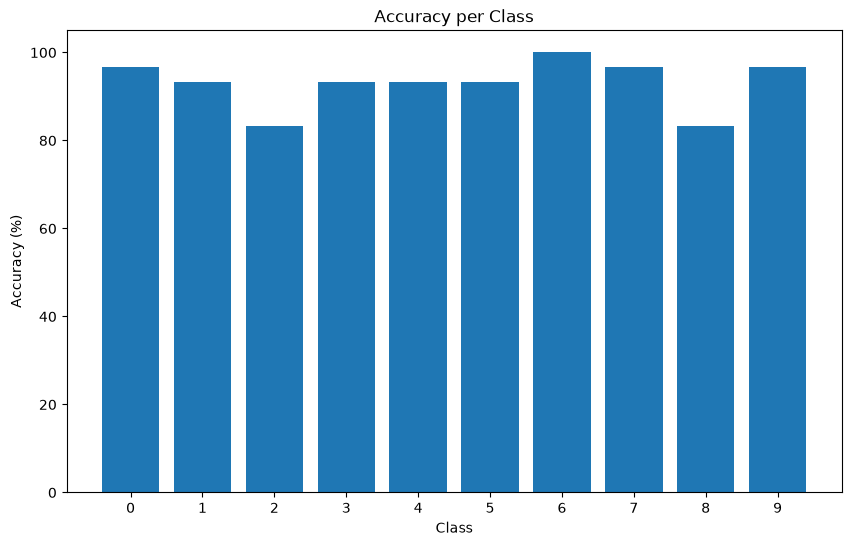

In [165]:
#compute accuracy on this test set, and compute accuracy per class and plot histogram of the accuracy per class

correct = 0
total = 0
class_correct = list(0. for i in range(n_classes))
class_total = list(0. for i in range(n_classes))
with torch.no_grad():
    for data in test_dataloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the test images: {100 * correct / total}%')

class_accuracies = []
for i in range(n_classes):
    accuracy = 100 * class_correct[i] / class_total[i]
    class_accuracies.append(accuracy)
    print(f'Accuracy of {test_dataset.classes[i]}: {accuracy}%')

#Plot the histogram of accuracies per class
plt.figure(figsize=(10,6))
plt.bar(range(n_classes), class_accuracies, align='center')
plt.xticks(range(n_classes), test_dataset.classes)
plt.xlabel('Class')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy per Class')
plt.show()